# **Topic Modeling Using LDA on IMDb Movie Reviews**

## **Objective**

* The objective of this notebook is to perform topic modeling on movie reviews using **Latent Dirichlet Allocation (LDA)**.
* This notebook aims to identify the main topics discussed in:

  * negative movie reviews,
  * positive movie reviews, and
  * the entire movie review dataset.
* The analysis helps us understand what reviewers commonly discuss when they express positive or negative opinions about movies.

## **Dataset**

* This notebook uses the **IMDb labelled review dataset** [Link to access](https://archive.ics.uci.edu/dataset/331/sentiment+labelled+sentences)
* Each review is assigned a sentiment label:

  * `0` = Negative sentiment
  * `1` = Positive sentiment

## What We Do in This Notebook

* Clean and preprocess the review text for topic modeling.
* Separate the reviews into negative, positive.
* Convert the cleaned text into a dictionary and corpus format.
* Build LDA topic models for:

  * negative reviews,
  * positive reviews, and
  * the full dataset.
* Evaluate the number of topics using **coherence score** and **perplexity**.
* Visualize the topics using **pyLDAvis**.


In [1]:
!pip install -q contractions emoji pyLDAvis textblob wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 3.5 MB/s eta 0:00:00


In [2]:
# basic import
import warnings
import logging
import re
import html
import string

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import nltk
import emoji
import contractions

from contractions import fix as expand_contractions
from bs4 import BeautifulSoup
from textblob import TextBlob
from wordcloud import WordCloud

from nltk import download
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer
from nltk.stem.snowball import SnowballStemmer

In [4]:
# nltk download
nltk_resources = [
    "stopwords",
    "punkt",
    "punkt_tab",
    "averaged_perceptron_tagger",
    "averaged_perceptron_tagger_eng",
    "wordnet",
    "omw-1.4"
]

for resource in nltk_resources:
    nltk.download(resource)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [5]:
# setting
# Show only error messages from sklearnex
logging.basicConfig()
logging.getLogger("SKLEARNEX").setLevel(logging.ERROR)

# Ignore warnings
warnings.filterwarnings("ignore")

# Seaborn theme
sns.set_theme(palette="Set3")

In [6]:
# text tools
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()
stemmer = SnowballStemmer("english")

#**Data import**

In [7]:
from google.colab import files
uploaded = files.upload()

Saving imdb_labelled.txt to imdb_labelled.txt


In [8]:
df = pd.read_csv(
    "imdb_labelled.txt",
    sep="\t",
    header=None,
    names=["text", "label"]
)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 748 entries, 0 to 747
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    748 non-null    object
 1   label   748 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 11.8+ KB


In [10]:
df.head()

,text,label
0,"A very, very, very slow-moving, aimless movie ...",0
1,Not sure who was more lost - the flat characte...,0
2,Attempting artiness with black & white and cle...,0
3,Very little music or anything to speak of.,0
4,The best scene in the movie was when Gerardo i...,1


# **Data Preprocessing**

In [11]:
# Initialize tools
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english')) | {""}
# Define preprocessing function
def preprocess_text(text):
    # Fast emoji replacement using regex
    text = emoji.demojize(text, delimiters=(":", ":"))
    # Normalize repeated characters
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    # Expand contractions using the contractions library
    text = expand_contractions(text)
    # Lowercase the text for uniformity
    text = text.lower()
    # Remove URLs
    text = re.sub(r"http\S+|www\S+", '', text)
    # Remove non-alphanumeric characters except emojis
    text = re.sub(r"[^\w\s]", '', text)
    # Remove numbers as they usually don't add meaning
    text = re.sub(r"\b\d+\b", '', text)
    # Remove excessive whitespace
    text = re.sub(r"\s+", ' ', text).strip()
    # Tokenize text into words
    tokens = word_tokenize(text)
    # Remove stop words
    tokens = [word for word in tokens if word not in stop_words]
    # Keep only words with more than 2 letters
    tokens = [word for word in tokens if len(word) > 2]
    # Lemmatize tokens to their base form
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    # Join tokens back into a single cleaned string
    return " ".join(tokens)

# Preprocess the 'Comment Text' column
df['Cleaned_Text'] = df['text'].fillna('').apply(preprocess_text)

In [12]:
df.head()

,text,label,Cleaned_Text
0,"A very, very, very slow-moving, aimless movie ...",0,slowmoving aimless movie distressed drifting y...
1,Not sure who was more lost - the flat characte...,0,sure lost flat character audience nearly half ...
2,Attempting artiness with black & white and cle...,0,attempting artiness black white clever camera ...
3,Very little music or anything to speak of.,0,little music anything speak
4,The best scene in the movie was when Gerardo i...,1,best scene movie gerardo trying find song keep...


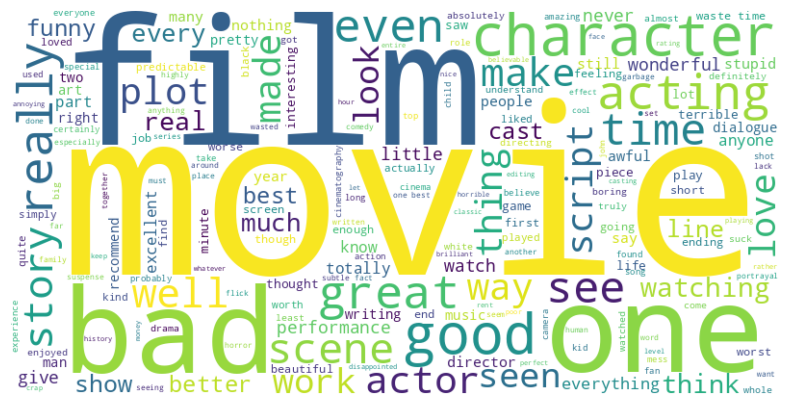

In [13]:
# Generate the word cloud from the processed content
text = " ".join(review for review in df['Cleaned_Text'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
#plt.title('Word Cloud of Processed Content')
plt.show()

# Topic Modelling

## Positive

In [14]:
po_df = df[df['label'] == 1]
neg_df = df[df['label'] == 0]

In [15]:
po_df.head()

,text,label,Cleaned_Text
4,The best scene in the movie was when Gerardo i...,1,best scene movie gerardo trying find song keep...
7,Saw the movie today and thought it was a good ...,1,saw movie today thought good effort good messa...
9,Loved the casting of Jimmy Buffet as the scien...,1,loved casting jimmy buffet science teacher
10,And those baby owls were adorable.,1,baby owl adorable
11,The movie showed a lot of Florida at it's best...,1,movie showed lot florida best made look appealing


In [16]:
neg_df.head()

,text,label,Cleaned_Text
0,"A very, very, very slow-moving, aimless movie ...",0,slowmoving aimless movie distressed drifting y...
1,Not sure who was more lost - the flat characte...,0,sure lost flat character audience nearly half ...
2,Attempting artiness with black & white and cle...,0,attempting artiness black white clever camera ...
3,Very little music or anything to speak of.,0,little music anything speak
5,"The rest of the movie lacks art, charm, meanin...",0,rest movie lack art charm meaning emptiness wo...


## Positive

   num_topics  coherence  log_perplexity    perplexity
0           5   0.444204       -7.588863    192.519775
1          10   0.457750       -7.890626    237.309412
2          15   0.476462      -10.257895   1224.430409
3          20   0.484956      -12.427198   5507.560997
4          25   0.461406      -13.723318  13524.784194
5          30   0.431484      -14.950370  31659.930742


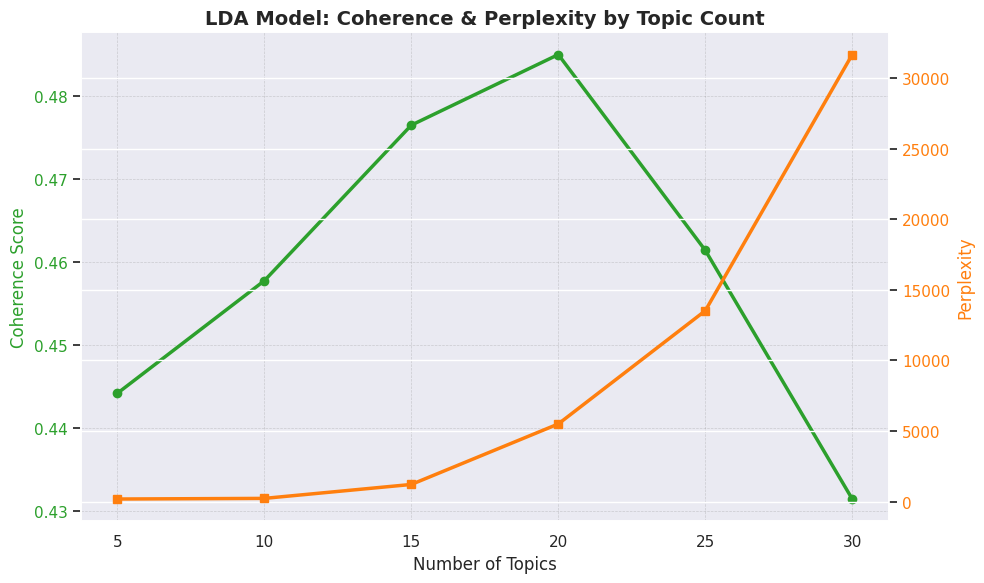

In [17]:
import gensim
from gensim import corpora
from gensim.models import CoherenceModel

# random seed
random_seed = 100
np.random.seed(random_seed)

# prepare data
processed_content = po_df["Cleaned_Text"].fillna("").astype(str).apply(lambda x: x.split())

# Remove empty documents
texts = [text for text in processed_content if len(text) > 0]

# Create dictionary
id2word = corpora.Dictionary(texts)

# Create corpus
corpus = [id2word.doc2bow(text) for text in texts]

# 3. COMPUTE COHERENCE & PERPLEXITY
def compute_metrics(dictionary, corpus, texts, start=5, limit=30, step=5):
    coherence_values = []
    perplexity_values = []
    log_perplexity_values = []
    model_list = []

    for num_topics in range(start, limit + 1, step):
        model = gensim.models.LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            random_state=100,
            update_every=2,
            chunksize=100,
            passes=10,
            alpha="auto",
            per_word_topics=True
        )

        model_list.append(model)

        # Coherence score
        coherence_model = CoherenceModel(
            model=model,
            texts=texts,
            dictionary=dictionary,
            coherence="c_v"
        )
        coherence_values.append(coherence_model.get_coherence())

        # Log perplexity
        log_perplexity = model.log_perplexity(corpus)
        log_perplexity_values.append(log_perplexity)

        # True perplexity
        perplexity = 2 ** (-log_perplexity)
        perplexity_values.append(perplexity)

    return model_list, coherence_values, perplexity_values, log_perplexity_values

# run model
start = 5
limit = 30
step = 5

model_list, coherence_values, perplexity_values, log_perplexity_values = compute_metrics(
    dictionary=id2word,
    corpus=corpus,
    texts=texts,
    start=start,
    limit=limit,
    step=step
)

# result table
x = list(range(start, limit + 1, step))

results_df = pd.DataFrame({
    "num_topics": x,
    "coherence": coherence_values,
    "log_perplexity": log_perplexity_values,
    "perplexity": perplexity_values
})

print(results_df)

# plot
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.grid(True, which="both", linestyle="--", linewidth=0.5, color="gray", alpha=0.3)

# Coherence plot
color = "tab:green"
ax1.set_xlabel("Number of Topics", fontsize=12)
ax1.set_ylabel("Coherence Score", color=color, fontsize=12)
ax1.plot(x, coherence_values, color=color, linewidth=2.5, marker="o", label="Coherence Score")
ax1.tick_params(axis="y", labelcolor=color)

# Perplexity plot
ax2 = ax1.twinx()
color = "tab:orange"
ax2.set_ylabel("Perplexity", color=color, fontsize=12)
ax2.plot(x, perplexity_values, color=color, linewidth=2.5, marker="s", label="Perplexity")
ax2.tick_params(axis="y", labelcolor=color)

plt.title("LDA Model: Coherence & Perplexity by Topic Count", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

In [18]:
# Conduct LDA with the optimal number of topics
optimal_num_topics = 15
lda_model_pos = gensim.models.LdaModel(corpus=corpus,
                                   id2word=id2word,
                                   num_topics=optimal_num_topics,
                                   random_state=random_seed,
                                   update_every=1,
                                   chunksize=100,
                                   passes=10,
                                   alpha='auto',
                                   per_word_topics=True)

# Output 1: 15 topics with top words (without probabilities)
print("Top 15 topics with words:\n")
topics = lda_model_pos.show_topics(num_topics=optimal_num_topics, num_words=10, formatted=False)
for idx, topic in topics:
    words = [word for word, _ in topic]
    print(f'Topic {idx}: {", ".join(words)}')

# Output 2: Words with their respective values for each topic
print("\nWords with values for each topic:\n")
topic_details = []
for idx in range(optimal_num_topics):
    topic_terms = lda_model_pos.get_topic_terms(idx, topn=10)
    topic_words = [(id2word[word_id], prob) for word_id, prob in topic_terms]
    topic_details.append((idx, topic_words))

for topic_num, topic_words in topic_details:
    print(f'Topic {topic_num}:')
    for word, prob in topic_words:
        print(f'  {word}: {prob:.4f}')
    print()

Top 15 topics with words:

Topic 0: short, made, watch, end, black, joy, classic, cartoon, night, along
Topic 1: acting, script, subtle, excellent, appreciate, directing, cinematography, gem, editing, put
Topic 2: like, still, see, cast, one, interesting, real, actor, come, top
Topic 3: saw, child, camera, martin, emilio, interplay, effective, since, type, work
Topic 4: movie, one, time, really, suck, best, well, great, ever, seen
Topic 5: way, music, liked, many, played, story, know, character, much, role
Topic 6: say, right, fan, perfect, sea, masterpiece, amount, seems, true, faux
Topic 7: special, become, part, take, ability, tell, time, predictable, audience, family
Topic 8: film, think, people, entire, feeling, superb, job, excellent, first, shot
Topic 9: recommend, comedy, truly, pretty, enjoyed, rather, actually, genuine, cinema, totally
Topic 10: good, watching, white, performance, man, beautiful, ending, brilliant, thought, scenery
Topic 11: two, never, every, tale, huston, e

In [19]:
# Visualize the topics
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
pyLDAvis.enable_notebook()
vis = gensimvis.prepare(lda_model_pos, corpus, id2word)
vis

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
4     -0.334466  0.023965       1        1  23.375400
14     0.025197 -0.104550       2        1   8.758466
8      0.062290  0.256942       3        1   8.201430
12    -0.038513 -0.013706       4        1   7.686149
13     0.013272 -0.044394       5        1   6.753758
2     -0.049167  0.032965       6        1   6.562521
5      0.014926 -0.048459       7        1   6.233546
11     0.012942 -0.019498       8        1   5.883261
10     0.022273 -0.032526       9        1   5.402080
9      0.049781 -0.009973      10        1   4.450742
0      0.042927 -0.022313      11        1   3.968081
1      0.054663  0.015790      12        1   3.556011
7      0.033152 -0.014045      13        1   3.378127
6      0.046247 -0.010098      14        1   3.254023
3      0.044477 -0.010098      15        1   2.536405, topic_info=           Term        Freq       Total Category  logprob  loglift
43         film  109.000000  109.000000  Default  30.0000  30.0000
5         movie  134.000000  134.000000  Default  29.0000  29.0000
11         good   30.000000   30.000000  Default  28.0000  28.0000
203        like   29.000000   29.000000  Default  27.0000  27.0000
111   character   40.000000   40.000000  Default  26.0000  26.0000
..          ...         ...         ...      ...      ...      ...
25          owl    0.327620    1.126561  Topic15  -5.6374   2.4394
218        work    1.435089    6.878212  Topic15  -4.1602   2.1073
465      robert    0.327628    1.609317  Topic15  -5.6373   2.0827
398         set    0.333656    5.219968  Topic15  -5.6191   0.9243
345  portraying    0.327628    1.638547  Topic15  -5.6373   2.0647

[541 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
1254     13  0.797563     ability
226       1  0.455829  absolutely
226       2  0.455829  absolutely
53        5  0.238028      acting
53       12  0.773591      acting
...     ...       ...         ...
315       4  0.950028      writer
151       7  0.758333     writing
94        1  0.857977     written
72        2  0.939401        year
713       1  0.874994         yet

[471 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[5, 15, 9, 13, 14, 3, 6, 12, 11, 10, 1, 2, 8, 7, 4])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Negative

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

   num_topics  coherence  log_perplexity   perplexity
0           5   0.460014       -7.472674   177.622896
1          10   0.494167       -7.701588   208.165578
2          15   0.497804       -8.727350   423.832271
3          20   0.441017       -9.818122   902.711716
4          25   0.413784      -10.450554  1399.362934
5          30   0.419189      -11.093032  2184.416227


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


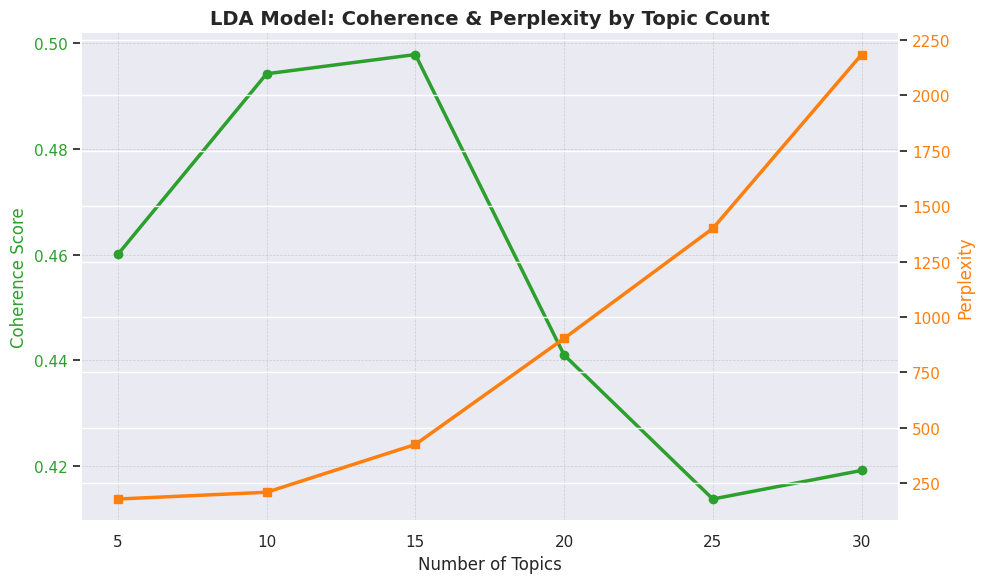

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [20]:
# random seed
random_seed = 100
np.random.seed(random_seed)

# prepare data
processed_content = neg_df["Cleaned_Text"].fillna("").astype(str).apply(lambda x: x.split())

# Remove empty documents
texts = [text for text in processed_content if len(text) > 0]

# Create dictionary
id2word = corpora.Dictionary(texts)

# Create corpus
corpus = [id2word.doc2bow(text) for text in texts]

# 3. COMPUTE COHERENCE & PERPLEXITY
def compute_metrics(dictionary, corpus, texts, start=5, limit=30, step=5):
    coherence_values = []
    perplexity_values = []
    log_perplexity_values = []
    model_list = []

    for num_topics in range(start, limit + 1, step):
        model = gensim.models.LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            random_state=100,
            update_every=2,
            chunksize=100,
            passes=10,
            alpha="auto",
            per_word_topics=True
        )

        model_list.append(model)

        # Coherence score
        coherence_model = CoherenceModel(
            model=model,
            texts=texts,
            dictionary=dictionary,
            coherence="c_v"
        )
        coherence_values.append(coherence_model.get_coherence())

        # Log perplexity
        log_perplexity = model.log_perplexity(corpus)
        log_perplexity_values.append(log_perplexity)

        # True perplexity
        perplexity = 2 ** (-log_perplexity)
        perplexity_values.append(perplexity)

    return model_list, coherence_values, perplexity_values, log_perplexity_values

# run model
start = 5
limit = 30
step = 5

model_list, coherence_values, perplexity_values, log_perplexity_values = compute_metrics(
    dictionary=id2word,
    corpus=corpus,
    texts=texts,
    start=start,
    limit=limit,
    step=step
)

# result table
x = list(range(start, limit + 1, step))

results_df = pd.DataFrame({
    "num_topics": x,
    "coherence": coherence_values,
    "log_perplexity": log_perplexity_values,
    "perplexity": perplexity_values
})

print(results_df)

# plot
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.grid(True, which="both", linestyle="--", linewidth=0.5, color="gray", alpha=0.3)

# Coherence plot
color = "tab:green"
ax1.set_xlabel("Number of Topics", fontsize=12)
ax1.set_ylabel("Coherence Score", color=color, fontsize=12)
ax1.plot(x, coherence_values, color=color, linewidth=2.5, marker="o", label="Coherence Score")
ax1.tick_params(axis="y", labelcolor=color)

# Perplexity plot
ax2 = ax1.twinx()
color = "tab:orange"
ax2.set_ylabel("Perplexity", color=color, fontsize=12)
ax2.plot(x, perplexity_values, color=color, linewidth=2.5, marker="s", label="Perplexity")
ax2.tick_params(axis="y", labelcolor=color)

plt.title("LDA Model: Coherence & Perplexity by Topic Count", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

In [21]:
# Conduct LDA with the optimal number of topics
optimal_num_topics = 10
lda_model_neg = gensim.models.LdaModel(corpus=corpus,
                                   id2word=id2word,
                                   num_topics=optimal_num_topics,
                                   random_state=random_seed,
                                   update_every=1,
                                   chunksize=100,
                                   passes=10,
                                   alpha='auto',
                                   per_word_topics=True)

# Output 1: 10 topics with top words
print("Top 15 topics with words:\n")
topics = lda_model_neg.show_topics(num_topics=optimal_num_topics, num_words=10, formatted=False)
for idx, topic in topics:
    words = [word for word, _ in topic]
    print(f'Topic {idx}: {", ".join(words)}')

# Output 2: Words with their respective values for each topic
print("\nWords with values for each topic:\n")
topic_details = []
for idx in range(optimal_num_topics):
    topic_terms = lda_model_neg.get_topic_terms(idx, topn=10)
    topic_words = [(id2word[word_id], prob) for word_id, prob in topic_terms]
    topic_details.append((idx, topic_words))

for topic_num, topic_words in topic_details:
    print(f'Topic {topic_num}:')
    for word, prob in topic_words:
        print(f'  {word}: {prob:.4f}')
    print()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Top 15 topics with words:

Topic 0: film, fails, level, bad, girl, suspense, embarrassing, unbelievable, example, looked
Topic 1: time, waste, thought, highly, problem, otherwise, start, truly, top, low
Topic 2: line, plot, film, know, totally, movie, little, story, better, understand
Topic 3: movie, film, like, good, bad, really, one, would, never, avoid
Topic 4: bad, one, movie, film, scene, script, ever, seen, worst, character
Topic 5: nothing, get, nonsense, minute, god, bore, movie, killer, spoiled, babysitting
Topic 6: awful, even, bad, writing, come, space, could, production, star, value
Topic 7: look, film, cheap, away, much, work, still, annoying, seemed, huge
Topic 8: acting, almost, worse, disappointed, even, expect, anything, black, could, final
Topic 9: guy, pretty, clichés, right, death, horror, picture, said, lead, stupid

Words with values for each topic:

Topic 0:
  film: 0.0254
  fails: 0.0210
  level: 0.0169
  bad: 0.0152
  girl: 0.0150
  suspense: 0.0135
  embarrass

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [22]:
# Visualize the topics
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
pyLDAvis.enable_notebook()
vis = gensimvis.prepare(lda_model_neg, corpus, id2word)
vis

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
4      0.131969 -0.172983       1        1  35.064669
3      0.229907  0.132311       2        1  18.605400
2     -0.104910  0.108664       3        1  14.670928
8     -0.044067 -0.035140       4        1   6.755014
7     -0.010351  0.031584       5        1   5.904099
6     -0.037250 -0.024828       6        1   4.745593
0     -0.027826 -0.002922       7        1   4.290896
9     -0.058592 -0.016774       8        1   4.244696
5     -0.052235 -0.002665       9        1   3.624456
1     -0.026645 -0.017246      10        1   2.094250, topic_info=      Term       Freq      Total Category  logprob  loglift
301   time  20.000000  20.000000  Default  30.0000  30.0000
344    bad  55.000000  55.000000  Default  29.0000  29.0000
25    even  21.000000  21.000000  Default  28.0000  28.0000
142   film  62.000000  62.000000  Default  27.0000  27.0000
4    movie  80.000000  80.000000  Default  26.0000  26.0000
..     ...        ...        ...      ...      ...      ...
990    top   0.551549   3.208687  Topic10  -4.9238   2.1051
281   shot   0.347493   2.982422  Topic10  -5.3858   1.7162
142   film   0.417928  62.179089  Topic10  -5.2013  -1.1365
463  bunch   0.217780   1.375669  Topic10  -5.8531   2.0228
199   life   0.212210   5.073104  Topic10  -5.8790   0.6918

[434 rows x 6 columns], token_table=      Topic      Freq         Term
term                              
57        3  0.949760   absolutely
1522      6  0.838461  achievement
15        1  0.604835       acting
15        2  0.100806       acting
15        4  0.252015       acting
...     ...       ...          ...
334       6  0.573728      writing
1512      3  0.841655        wrong
497       7  0.754711         yeah
905       1  0.950877         year
336       7  0.622230          yes

[428 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[5, 4, 3, 9, 8, 7, 1, 10, 6, 2])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# General

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

   num_topics  coherence  log_perplexity    perplexity
0           5   0.405956       -7.898260    238.568513
1          10   0.459069       -8.101469    274.653595
2          15   0.539633      -11.235449   2411.054638
3          20   0.493915      -12.756667   6920.532325
4          25   0.473911      -14.067563  17169.527627
5          30   0.434760      -15.778909  56224.421523


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

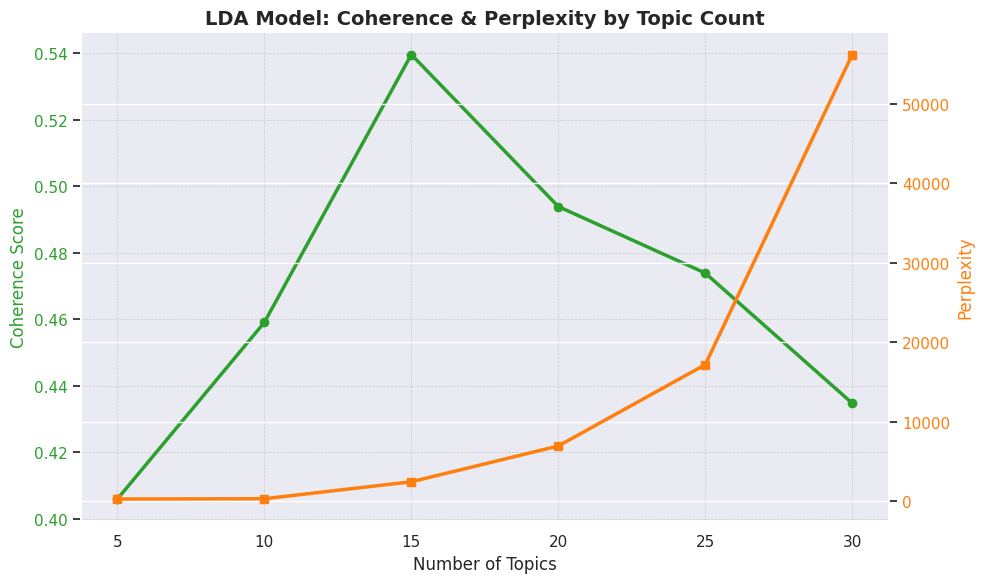

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [23]:
# random seed
random_seed = 100
np.random.seed(random_seed)

# prepare data
processed_content = df["Cleaned_Text"].fillna("").astype(str).apply(lambda x: x.split())

# Remove empty documents
texts = [text for text in processed_content if len(text) > 0]

# Create dictionary
id2word = corpora.Dictionary(texts)

# Create corpus
corpus = [id2word.doc2bow(text) for text in texts]

# 3. COMPUTE COHERENCE & PERPLEXITY
def compute_metrics(dictionary, corpus, texts, start=5, limit=30, step=5):
    coherence_values = []
    perplexity_values = []
    log_perplexity_values = []
    model_list = []

    for num_topics in range(start, limit + 1, step):
        model = gensim.models.LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            random_state=100,
            update_every=2,
            chunksize=100,
            passes=10,
            alpha="auto",
            per_word_topics=True
        )

        model_list.append(model)

        # Coherence score
        coherence_model = CoherenceModel(
            model=model,
            texts=texts,
            dictionary=dictionary,
            coherence="c_v"
        )
        coherence_values.append(coherence_model.get_coherence())

        # Log perplexity
        log_perplexity = model.log_perplexity(corpus)
        log_perplexity_values.append(log_perplexity)

        # True perplexity
        perplexity = 2 ** (-log_perplexity)
        perplexity_values.append(perplexity)

    return model_list, coherence_values, perplexity_values, log_perplexity_values

# run model
start = 5
limit = 30
step = 5

model_list, coherence_values, perplexity_values, log_perplexity_values = compute_metrics(
    dictionary=id2word,
    corpus=corpus,
    texts=texts,
    start=start,
    limit=limit,
    step=step
)

# result table
x = list(range(start, limit + 1, step))

results_df = pd.DataFrame({
    "num_topics": x,
    "coherence": coherence_values,
    "log_perplexity": log_perplexity_values,
    "perplexity": perplexity_values
})

print(results_df)

# plot
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.grid(True, which="both", linestyle="--", linewidth=0.5, color="gray", alpha=0.3)

# Coherence plot
color = "tab:green"
ax1.set_xlabel("Number of Topics", fontsize=12)
ax1.set_ylabel("Coherence Score", color=color, fontsize=12)
ax1.plot(x, coherence_values, color=color, linewidth=2.5, marker="o", label="Coherence Score")
ax1.tick_params(axis="y", labelcolor=color)

# Perplexity plot
ax2 = ax1.twinx()
color = "tab:orange"
ax2.set_ylabel("Perplexity", color=color, fontsize=12)
ax2.plot(x, perplexity_values, color=color, linewidth=2.5, marker="s", label="Perplexity")
ax2.tick_params(axis="y", labelcolor=color)

plt.title("LDA Model: Coherence & Perplexity by Topic Count", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

In [24]:
# Conduct LDA with the optimal number of topics
optimal_num_topics = 15
lda_model = gensim.models.LdaModel(corpus=corpus,
                                   id2word=id2word,
                                   num_topics=optimal_num_topics,
                                   random_state=random_seed,
                                   update_every=1,
                                   chunksize=100,
                                   passes=10,
                                   alpha='auto',
                                   per_word_topics=True)

# Output 1: 15 topics with top words (without probabilities)
print("Top 15 topics with words:\n")
topics = lda_model.show_topics(num_topics=optimal_num_topics, num_words=10, formatted=False)
for idx, topic in topics:
    words = [word for word, _ in topic]
    print(f'Topic {idx}: {", ".join(words)}')

# Output 2: Words with their respective values for each topic
print("\nWords with values for each topic:\n")
topic_details = []
for idx in range(optimal_num_topics):
    topic_terms = lda_model.get_topic_terms(idx, topn=10)
    topic_words = [(id2word[word_id], prob) for word_id, prob in topic_terms]
    topic_details.append((idx, topic_words))

for topic_num, topic_words in topic_details:
    print(f'Topic {topic_num}:')
    for word, prob in topic_words:
        print(f'  {word}: {prob:.4f}')
    print()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Top 15 topics with words:

Topic 0: watching, way, much, liked, beautiful, house, horrible, scenery, sucked, yeah
Topic 1: make, life, little, music, nothing, quite, action, fact, simply, believable
Topic 2: bad, look, loved, predictable, away, since, flick, tale, single, casting
Topic 3: two, year, first, could, understand, watched, however, series, chemistry, long
Topic 4: definitely, worth, done, seeing, classic, loneliness, written, acted, embarrassing, question
Topic 5: plot, sea, fun, childhood, masterpiece, perfect, hilarious, clever, theme, generally
Topic 6: going, experience, gem, rent, cool, put, last, night, problem, playing
Topic 7: character, acting, see, well, real, also, made, better, performance, dialogue
Topic 8: script, advise, politically, correct, see, virtue, regrettable, production, suck, rough
Topic 9: time, waste, people, enjoyed, entire, awful, fan, want, subtle, word
Topic 10: truly, slow, instead, whiny, found, budget, moment, moving, main, happened
Topic 11

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [25]:
# Visualize the topics
pyLDAvis.enable_notebook()
vis = gensimvis.prepare(lda_model, corpus, id2word)
vis

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
11     0.420612 -0.073869       1        1  39.319720
7      0.060441  0.346008       2        1  19.686568
9     -0.024568 -0.023056       3        1   9.137340
12    -0.041798 -0.035084       4        1   5.431281
3     -0.037678 -0.013025       5        1   4.252322
2     -0.038281 -0.026315       6        1   4.020325
1     -0.039523 -0.027053       7        1   3.826120
0     -0.038822 -0.022478       8        1   2.492468
5     -0.040422 -0.022905       9        1   2.476557
4     -0.038414 -0.014648      10        1   2.192117
6     -0.037929 -0.019672      11        1   2.077368
14    -0.036531 -0.018157      12        1   1.581281
10    -0.037249 -0.018645      13        1   1.403708
13    -0.036310 -0.017603      14        1   1.247193
8     -0.033528 -0.013498      15        1   0.855631, topic_info=           Term        Freq       Total Category  logprob  loglift
98         film  338.000000  338.000000  Default  30.0000  30.0000
4         movie  323.000000  323.000000  Default  29.0000  29.0000
450         bad   51.000000   51.000000  Default  28.0000  28.0000
357        time   64.000000   64.000000  Default  27.0000  27.0000
8     character   90.000000   90.000000  Default  26.0000  26.0000
...         ...         ...         ...      ...      ...      ...
2427      kudos    0.019872    0.837511  Topic15  -8.0458   1.0200
2532     puppet    0.019924    0.850643  Topic15  -8.0432   1.0070
2029      force    0.019938    0.858907  Topic15  -8.0425   0.9981
886        hole    0.019929    0.860774  Topic15  -8.0429   0.9955
1081     around    0.019923    0.920733  Topic15  -8.0433   0.9278

[527 rows x 6 columns], token_table=      Topic      Freq     Term
term                          
408      10  0.812568    acted
15        2  0.986733   acting
777       7  0.832540   action
124       1  0.990291    actor
778       1  0.976259  actress
...     ...       ...      ...
389       3  0.971653  writing
390      10  0.722543  written
627       8  0.722663     yeah
395       5  0.918164     year
391      13  0.748693      yes

[293 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[12, 8, 10, 13, 4, 3, 2, 1, 6, 5, 7, 15, 11, 14, 9])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

# **Citing This notebook**

If you use this notebook in your work, please cite it as follows:

Linh, H. (2026). Machine Learning for Business. Lecture examples and exercises. (Version 1.0.0). URL: https://github.com/MsLinhEIU/MIS-451---Machine-Learning-for-Business-Analytics/tree/main